# Clasificador MLP Clásico

Clasificación binaria sobre el dataset Iris usando un Perceptrón Multicapa (MLP),
una red neuronal densa clásica.

Este notebook es la línea base clásica para el experimento `neural_network`.  
Los resultados se guardan en `mlp_results.json` para su uso en `comparison/comparison.ipynb`.

**Variable de configuración:** `N_FEATURES` controla cuántas características se usan (2 o 4).  
Para la versión de 4 características, los resultados se guardan automáticamente en `mlp_results_4f.json`.

## Importaciones

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## Configuración

In [ ]:
N_FEATURES     = 2      # 2 or 4
TEST_SIZE   = 0.2       # fraction of data held out for testing
RANDOM_SEED = 42        # reproducibility
MAX_ITER    = 500       # maximum training iterations

# Architecture: two hidden layers.
# Kept intentionally small to match the parameter count of the QNN.
# With N_FEATURES   = 2: (2 -> 4 -> 4 -> 1) = 8 + 4 + 4 + 1 = ~30 parameters
# With N_FEATURES   = 2: (4 -> 8 -> 4 -> 1) = 32 + 8 + 4 + 1 = ~60 parameters
HIDDEN_LAYERS = (4, 4) if N_FEATURES == 2 else (8, 4)

RESULTS_FILE = "mlp_results.json" if N_FEATURES == 2 else "mlp_results_4f.json"

print(f"Configuration  : N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}")
print(f"Hidden layers  : {HIDDEN_LAYERS}")
print(f"Results file   : {RESULTS_FILE}")

Configuration  : N_FEATURES=2, MAX_ITER=500
Hidden layers  : (4, 4)
Results file   : mlp_results.json


## Dataset

Preprocesamiento idéntico al de los otros experimentos: Iris restringido a las clases 1 y 2
(Versicolor vs Virginica), escalado a [0, 1], misma partición train/test y misma semilla aleatoria.

In [3]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

print(f"Total samples : {len(X_scaled)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features      : {feature_names}")
print(f"Class balance (train): {np.bincount(y_train)}")

Total samples : 100
Train samples : 80
Test samples  : 20
Features      : ['petal length', 'petal width']
Class balance (train): [40 40]


## Algoritmo Clásico. MLP

Un Perceptrón Multicapa es una red neuronal de propagación hacia adelante totalmente conectada.
Cada neurona calcula una suma ponderada de sus entradas y aplica una función de activación no lineal
(ReLU aquí). El entrenamiento usa retropropagación: los gradientes de la pérdida se calculan
analíticamente y los pesos se actualizan con el optimizador Adam.

**Elección de arquitectura:** las capas ocultas se mantienen deliberadamente pequeñas para que el
número total de parámetros entrenables sea comparable al del ansatz de la QNN. Esto hace la
comparación más justa en términos de capacidad del modelo.

In [4]:
def build_mlp():
    return MLPClassifier(
        hidden_layer_sizes = HIDDEN_LAYERS,
        activation         = "relu",
        solver             = "adam",
        max_iter           = MAX_ITER,
        random_state       = RANDOM_SEED,
        early_stopping     = False,
    )


def count_mlp_parameters(model):
    """Count total trainable parameters (weights + biases) after fitting."""
    total = 0
    for coef in model.coefs_:
        total += coef.size
    for intercept in model.intercepts_:
        total += intercept.size
    return total


mlp = build_mlp()

t0         = time.perf_counter()
mlp.fit(X_train, y_train)
train_time = time.perf_counter() - t0

n_params = count_mlp_parameters(mlp)

print(f"Training time      : {train_time:.4f} s")
print(f"Iterations run     : {mlp.n_iter_}")
print(f"Trainable parameters: {n_params}")

Training time      : 0.1233 s
Iterations run     : 500
Trainable parameters: 37


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Evaluación

In [5]:
y_pred_train = mlp.predict(X_train)
y_pred_test  = mlp.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test  = accuracy_score(y_test,  y_pred_test)

cv_scores = cross_val_score(mlp, X_scaled, y_full, cv=5, scoring="accuracy")

print(f"Train accuracy : {acc_train:.4f}")
print(f"Test accuracy  : {acc_test:.4f}")
print(f"CV accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred_test,
                             target_names=["Versicolor", "Virginica"]))

/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Train accuracy : 0.9750
Test accuracy  : 0.8000
CV accuracy    : 0.9500 ± 0.0447

              precision    recall  f1-score   support

  Versicolor       0.75      0.90      0.82        10
   Virginica       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



/home/david/Desktop/TFG/Qiskit/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


## Gráficas

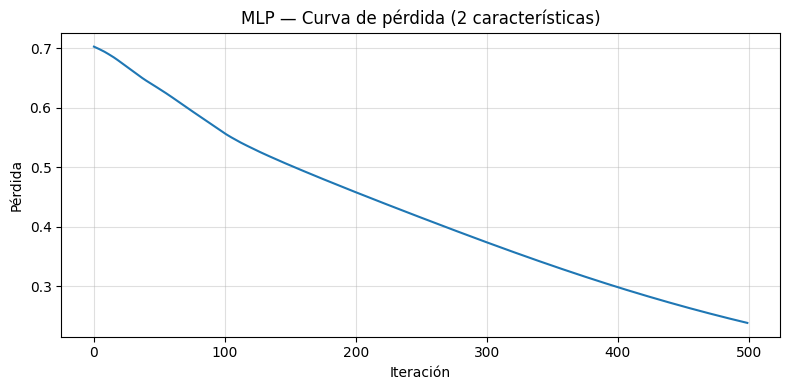

In [ ]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, color="tab:blue")
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title(f"MLP — Curva de pérdida ({N_FEATURES} características)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"mlp_loss_curve{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

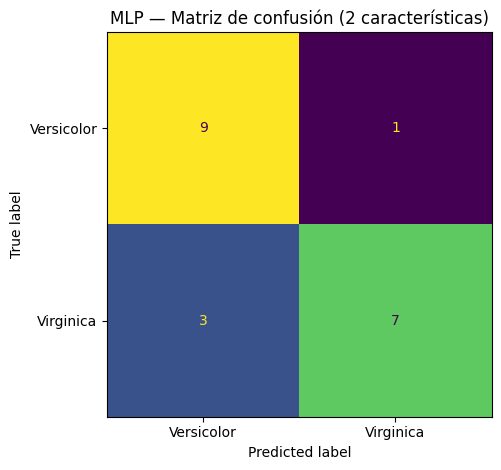

In [ ]:
# Confusion matrix
cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"MLP — Matriz de confusión ({N_FEATURES} características)")
plt.tight_layout()
plt.savefig(f"mlp_confusion_matrix{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

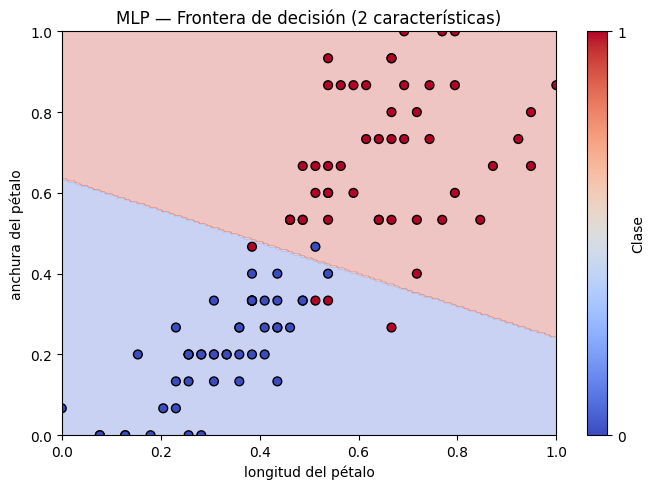

In [ ]:
# Decision boundary (only for 2 features) 
if N_FEATURES == 2:
    h = 0.005
    xx, yy = np.meshgrid(np.arange(0, 1 + h, h), np.arange(0, 1 + h, h))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_full,
                          cmap="coolwarm", edgecolors="k", s=40)
    _es = {
        "petal length"     : "longitud del pétalo",
        "petal width"      : "anchura del pétalo",
        "sepal length (cm)": "longitud del sépalo (cm)",
        "sepal width (cm)" : "anchura del sépalo (cm)",
        "petal length (cm)": "longitud del pétalo (cm)",
        "petal width (cm)" : "anchura del pétalo (cm)",
    }
    plt.colorbar(scatter, ticks=[0, 1], label="Clase")
    plt.xlabel(_es.get(feature_names[0], feature_names[0]))
    plt.ylabel(_es.get(feature_names[1], feature_names[1]))
    plt.title("MLP — Frontera de decisión (2 características)")
    plt.tight_layout()
    plt.savefig("mlp_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Guardar Resultados

In [ ]:
results = {
    # Experiment metadata 
    "model"          : "MLP",
    "n_features"     : N_FEATURES,
    "feature_names"  : feature_names,
    "n_train"        : int(len(X_train)),
    "n_test"         : int(len(X_test)),
    "random_seed"    : RANDOM_SEED,

    # Architecture 
    "hidden_layers"  : list(HIDDEN_LAYERS),
    "activation"     : "relu",
    "optimizer"      : "adam",
    "n_parameters"   : int(n_params),

    # Timing
    "train_time_s"   : float(train_time),
    "n_iter"         : int(mlp.n_iter_),

    # Accuracy 
    "accuracy_test"  : float(acc_test),
    "accuracy_train" : float(acc_train),
    "cv_mean"        : float(cv_scores.mean()),
    "cv_std"         : float(cv_scores.std()),
    "cv_scores"      : cv_scores.tolist(),

    # Loss history 
    "loss_curve"     : mlp.loss_curve_,

    # Predictions 
    "y_test"         : y_test.tolist(),
    "y_pred_test"    : y_pred_test.tolist(),
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
print(json.dumps({k: v for k, v in results.items()
                  if k not in ("cv_scores", "loss_curve", "y_test", "y_pred_test")}, indent=2))

Results saved to mlp_results.json
{
  "model": "MLP",
  "n_features": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "hidden_layers": [
    4,
    4
  ],
  "activation": "relu",
  "optimizer": "adam",
  "n_parameters": 37,
  "train_time_s": 0.12327831599395722,
  "n_iter": 500,
  "accuracy_test": 0.8,
  "accuracy_train": 0.975,
  "cv_mean": 0.95,
  "cv_std": 0.04472135954999579
}
